In [17]:
from pathlib import Path
import sys

# Add project root to path
ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

PATH    = ROOT / "data" / "RequestForPayment.xes"
CACHE   = ROOT / "cache"
RESULTS = ROOT / "results"

CACHE.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("Data file exists:", PATH.exists())

Data file exists: True


In [18]:

import pm4py

log = pm4py.read_xes(str(PATH))
print(f"Events: {len(log):,}")
print(f"Cases:  {log['case:concept:name'].nunique():,}")
print(f"Period: {log['time:timestamp'].min()} → {log['time:timestamp'].max()}")
log.head()

parsing log, completed traces :: 100%|██████████| 6886/6886 [00:01<00:00, 5038.41it/s]


Events: 36,796
Cases:  6,886
Period: 2017-01-09 09:17:18+00:00 → 2019-08-08 14:57:18+00:00


,id,org:resource,concept:name,time:timestamp,org:role,case:Rfp_id,case:Project,case:Task,case:concept:name,case:OrganizationalEntity,case:Cost Type,case:RequestedAmount,case:Activity,case:RfpNumber
0,st_step 148220_0,STAFF MEMBER,Request For Payment SUBMITTED by EMPLOYEE,2017-01-09 09:17:18+00:00,EMPLOYEE,request for payment 148214,project 148216,UNKNOWN,request for payment 148214,organizational unit 65463,0,34.336343,UNKNOWN,request for payment number 148215
1,st_step 148221_0,STAFF MEMBER,Request For Payment FINAL_APPROVED by SUPERVISOR,2017-01-09 09:18:00+00:00,SUPERVISOR,request for payment 148214,project 148216,UNKNOWN,request for payment 148214,organizational unit 65463,0,34.336343,UNKNOWN,request for payment number 148215
2,st_step 148222_0,STAFF MEMBER,Request For Payment REJECTED by MISSING,2017-01-10 12:42:32+00:00,MISSING,request for payment 148214,project 148216,UNKNOWN,request for payment 148214,organizational unit 65463,0,34.336343,UNKNOWN,request for payment number 148215
3,st_step 148219_0,STAFF MEMBER,Request For Payment SUBMITTED by EMPLOYEE,2017-03-03 09:51:13+00:00,EMPLOYEE,request for payment 148214,project 148216,UNKNOWN,request for payment 148214,organizational unit 65463,0,34.336343,UNKNOWN,request for payment number 148215
4,st_step 148218_0,STAFF MEMBER,Request For Payment APPROVED by PRE_APPROVER,2017-03-03 09:51:42+00:00,PRE_APPROVER,request for payment 148214,project 148216,UNKNOWN,request for payment 148214,organizational unit 65463,0,34.336343,UNKNOWN,request for payment number 148215


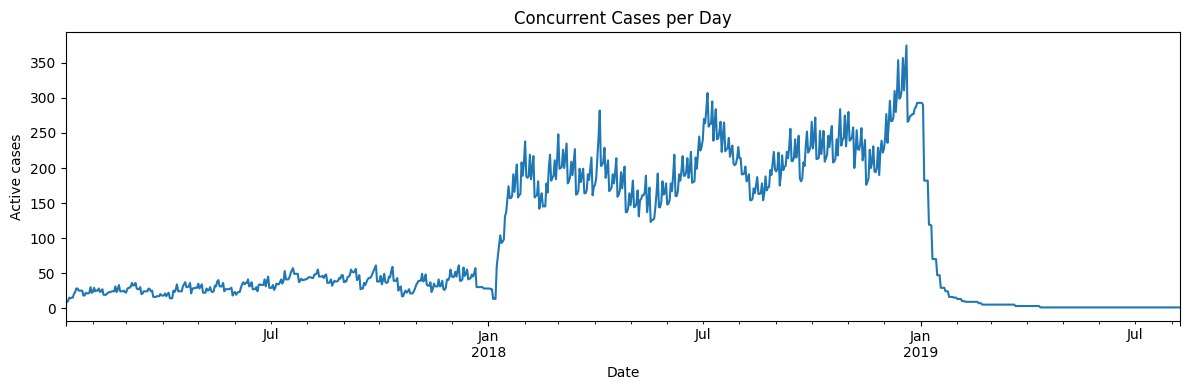

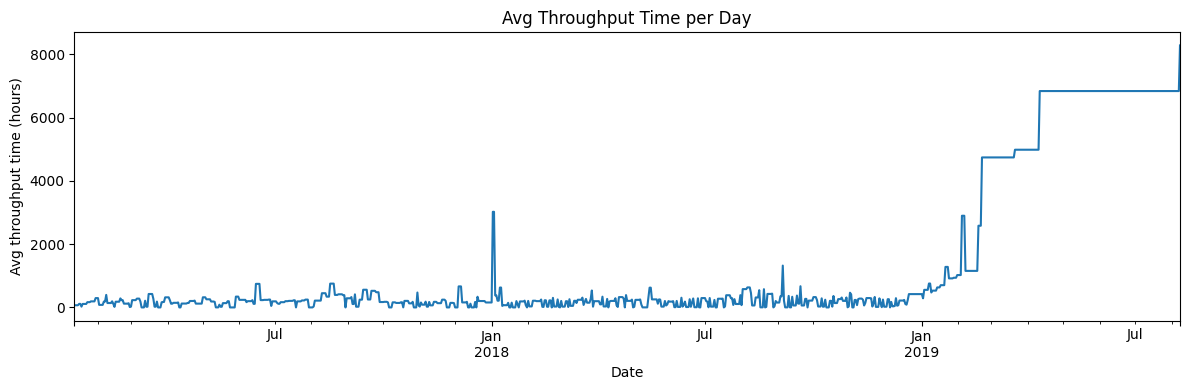

In [19]:
from time_series_creation import *
avg_cc=create_concurrent_cases_timeseries(log)
avg_tt=create_avg_throughtput_time_timeseries(log)

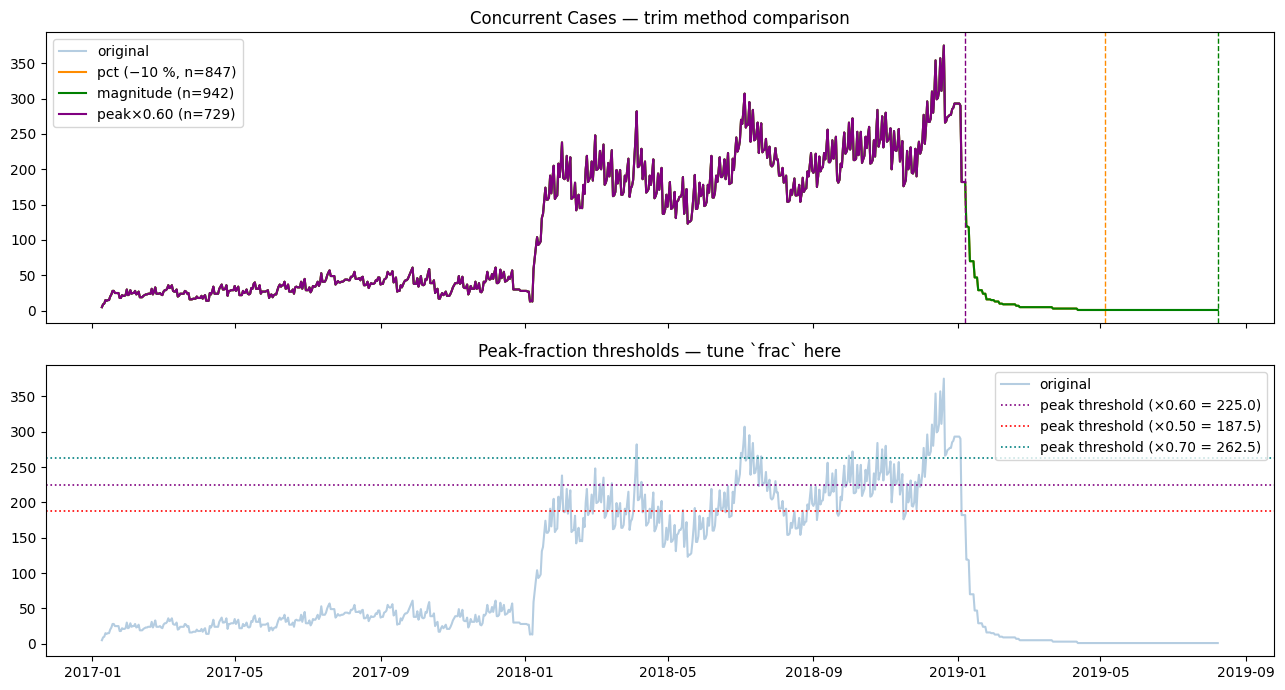

In [20]:
from time_series_preprocessing import *
from setttings import *
# ── diagnostic: compare all trim methods on avg_cc ───────────────────────────
_cc_pct = trim_tail_pct(avg_cc, pct=0.10)
_cc_mag = trim_tail_magnitude(avg_cc, k=1.5, window=7)
_cc_pk  = trim_tail_peak(avg_cc, frac=0.60, window=7)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(avg_cc.index, avg_cc, color="steelblue", alpha=0.4, label="original")
ax.plot(_cc_pct.index, _cc_pct, color="darkorange", label=f"pct (−10 %, n={len(_cc_pct)})")
ax.plot(_cc_mag.index, _cc_mag, color="green",      label=f"magnitude (n={len(_cc_mag)})")
ax.plot(_cc_pk.index,  _cc_pk,  color="purple",     label=f"peak×0.60 (n={len(_cc_pk)})")
for s, c in [(_cc_pct, "darkorange"), (_cc_mag, "green"), (_cc_pk, "purple")]:
    ax.axvline(s.index[-1], linestyle="--", color=c, linewidth=1)
ax.set_title("Concurrent Cases — trim method comparison")
ax.legend()

ax = axes[1]
ax.plot(avg_cc.index, avg_cc, color="steelblue", alpha=0.4, label="original")
ax.axhline(0.60 * avg_cc.max(), linestyle=":", color="purple",  linewidth=1.2, label=f"peak threshold (×0.60 = {0.60*avg_cc.max():.1f})")
ax.axhline(0.50 * avg_cc.max(), linestyle=":", color="red",     linewidth=1.2, label=f"peak threshold (×0.50 = {0.50*avg_cc.max():.1f})")
ax.axhline(0.70 * avg_cc.max(), linestyle=":", color="teal",    linewidth=1.2, label=f"peak threshold (×0.70 = {0.70*avg_cc.max():.1f})")
ax.set_title("Peak-fraction thresholds — tune `frac` here")
ax.legend()

plt.tight_layout()
plt.show()

CC: 942 → 706  (dropped 236 rows)
TT: 939 → 704  (dropped 235 rows)

CC  — train: 494, val: 70, test: 142
TT  — train: 492, val: 70, test: 142


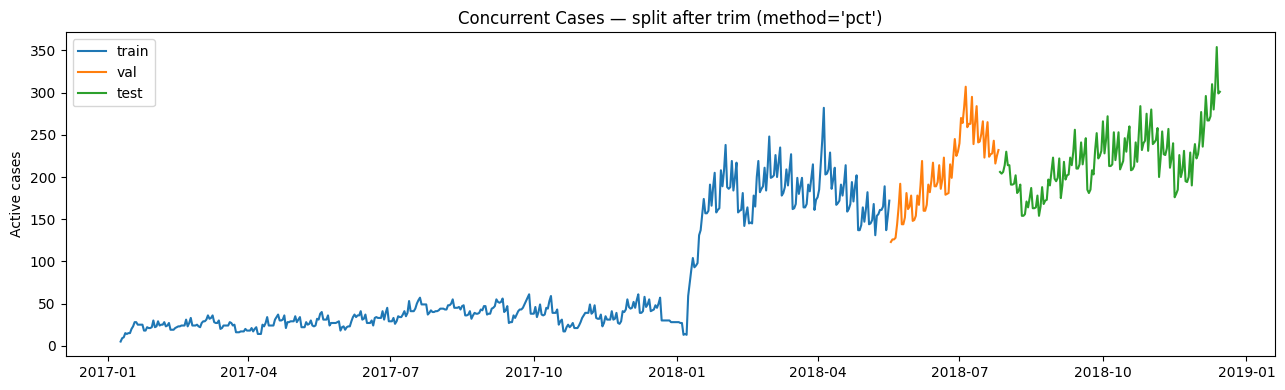

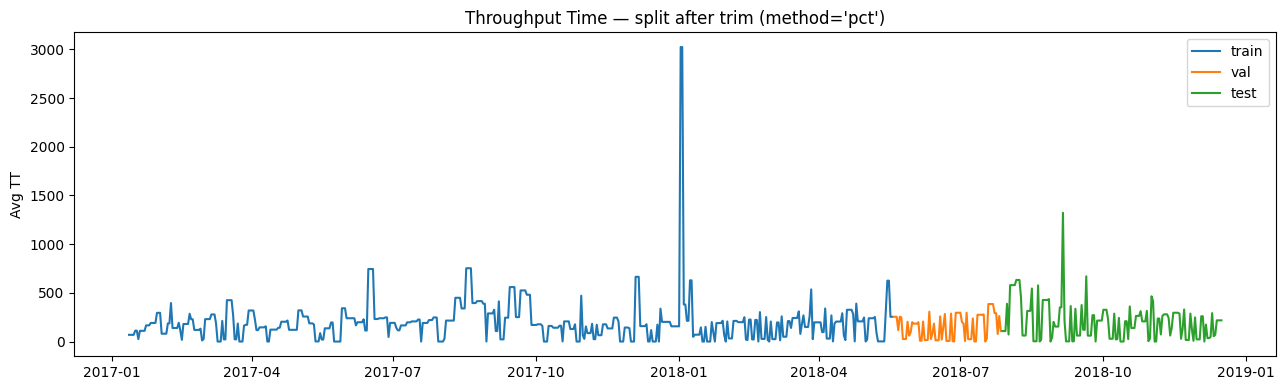

In [29]:
# ── truncation parameters ─────────────────────────────────────────────────────
TRIM_METHOD = "pct"    # "pct" | "magnitude" | "peak" | None
TRIM_PCT    = 0.25      # used when method="pct"
TRIM_K      = 1.5       # used when method="magnitude"
TRIM_FRAC   = 0.60      # used when method="peak": cut below frac * max
TRIM_WINDOW = 7         # rolling window (all methods)

set_global_seed(1904)
cfg = Split3WayConfig(train_frac=0.7, val_frac=0.1, test_frac=0.2)

avg_cc_trim = apply_trim(avg_cc, TRIM_METHOD, pct=TRIM_PCT, k=TRIM_K, frac=TRIM_FRAC, window=TRIM_WINDOW)
avg_tt_trim = apply_trim(avg_tt, TRIM_METHOD, pct=TRIM_PCT, k=TRIM_K, frac=TRIM_FRAC, window=TRIM_WINDOW)

print(f"CC: {len(avg_cc)} → {len(avg_cc_trim)}  (dropped {len(avg_cc) - len(avg_cc_trim)} rows)")
print(f"TT: {len(avg_tt)} → {len(avg_tt_trim)}  (dropped {len(avg_tt) - len(avg_tt_trim)} rows)")

train_cc, val_cc, test_cc = split_timeseries(avg_cc_trim, cfg)
train_tt, val_tt, test_tt = split_timeseries(avg_tt_trim, cfg)

print(f"\nCC  — train: {len(train_cc)}, val: {len(val_cc)}, test: {len(test_cc)}")
print(f"TT  — train: {len(train_tt)}, val: {len(val_tt)}, test: {len(test_tt)}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_cc.index, train_cc, label="train")
ax.plot(val_cc.index,   val_cc,   label="val")
ax.plot(test_cc.index,  test_cc,  label="test")
ax.set_title(f"Concurrent Cases — split after trim (method={TRIM_METHOD!r})")
ax.set_ylabel("Active cases")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_tt.index, train_tt, label="train")
ax.plot(val_tt.index,   val_tt,   label="val")
ax.plot(test_tt.index,  test_tt,  label="test")
ax.set_title(f"Throughput Time — split after trim (method={TRIM_METHOD!r})")
ax.set_ylabel("Avg TT")
ax.legend()
plt.tight_layout()
plt.show()

lw## Forecasting — Naive / ETS / SARIMAX

In [30]:
from time_series_prediction import (
    forecast_naive, forecast_naive_recent, forecast_seasonal_naive,
    forecast_ets, forecast_sarimax, forecast_ridge, forecast_gru, forecast_nbeats,
    tune_on_val, run_pipeline,
    SEASONAL_NAIVE_GRID, ETS_GRID, SARIMAX_GRID, RIDGE_GRID, GRU_GRID, NBEATS_GRID,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print(f"Seasonal naive grid: {len(SEASONAL_NAIVE_GRID)} candidates")
print(f"ETS grid:            {len(ETS_GRID)} candidates")
print(f"SARIMAX grid:        {len(SARIMAX_GRID)} candidates")
print(f"Ridge grid:          {len(RIDGE_GRID)} candidates")
print(f"GRU grid:            {len(GRU_GRID)} candidates")
print(f"N-BEATS grid:        {len(NBEATS_GRID)} candidates")

Seasonal naive grid: 3 candidates
ETS grid:            30 candidates
SARIMAX grid:        16 candidates
Ridge grid:          12 candidates
GRU grid:            4 candidates
N-BEATS grid:        6 candidates


In [31]:
RIDGE_GRID

[{'lags': 7, 'alpha': 0.01, 'add_time_features': True},
 {'lags': 7, 'alpha': 0.1, 'add_time_features': True},
 {'lags': 7, 'alpha': 1.0, 'add_time_features': True},
 {'lags': 7, 'alpha': 10.0, 'add_time_features': True},
 {'lags': 14, 'alpha': 0.01, 'add_time_features': True},
 {'lags': 14, 'alpha': 0.1, 'add_time_features': True},
 {'lags': 14, 'alpha': 1.0, 'add_time_features': True},
 {'lags': 14, 'alpha': 10.0, 'add_time_features': True},
 {'lags': 28, 'alpha': 0.01, 'add_time_features': True},
 {'lags': 28, 'alpha': 0.1, 'add_time_features': True},
 {'lags': 28, 'alpha': 1.0, 'add_time_features': True},
 {'lags': 28, 'alpha': 10.0, 'add_time_features': True}]

In [32]:
preds_cc = run_pipeline(train_cc, val_cc, test_cc, label="ConcurrentCases")

[ConcurrentCases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 7}  val_MSE=3953.2714
[ConcurrentCases] Tuning ets (30 candidates) …
  best: {'error': 'mul', 'trend': 'add', 'damped_trend': False, 'seasonal': 'mul', 'seasonal_periods': 7}  val_MSE=616.7446
[ConcurrentCases] Tuning sarimax (16 candidates) …
  best: {'order': (0, 1, 1), 'seasonal_order': (1, 0, 0, 7)}  val_MSE=982.6498
[ConcurrentCases] Tuning ridge (12 candidates) …
  best: {'lags': 7, 'alpha': 0.01, 'add_time_features': True}  val_MSE=7291.3061
[ConcurrentCases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.954189
  [GRU] epoch 2/50  loss=0.791316
  [GRU] epoch 3/50  loss=0.545571
  [GRU] epoch 4/50  loss=0.223061
  [GRU] epoch 5/50  loss=0.102295
  [GRU] epoch 6/50  loss=0.081670
  [GRU] epoch 7/50  loss=0.077706
  [GRU] epoch 8/50  loss=0.075932
  [GRU] epoch 9/50  loss=0.074507
  [GRU] epoch 10/50  loss=0.073544
  [GRU] epoch 11/50  loss=0.072401
  [GRU] epoch 12/50  loss=0.071310
  [GRU] epoch 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 45.5 K | train | 0    
---------------------------------------------------------------------
43.2 K    Trainable params
2.3 K     Non-trainable params
45.5 K    Total params
0.182     Total estim

Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 48.00it/s, train_loss=0.00371]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 47.81it/s, train_loss=0.00371]


...

Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 42.35it/s, train_loss=0.0274]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 41.98it/s, train_loss=0.0274]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 30.98it/s]

Model                      MSE         MAE
--------------------------------------------
naive                1414.6479     30.1268
naive_recent          625.4577     19.5845
seasonal_naive       1249.2042     27.7676
ets                 11605.0784     95.7511
sarimax              5162.8347     60.4526
ridge                2024.9004     37.4971
gru                  1547.0916     30.7779
nbeats               1952.1837     36.4128


In [ ]:
COLORS = {
    "naive":          "red",
    "naive_recent":   "salmon",
    "seasonal_naive": "darkorange",
    "ets":            "purple",
    "sarimax":        "saddlebrown",
    "ridge":          "steelblue",
    "gru":            "darkgreen",
    "nbeats":         "deeppink",
}

def plot_forecasts(train, val, test, preds, title, save_path=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train.index, train, color="steelblue", label="train")
    ax.plot(val.index,   val,   color="orange",    label="val")
    ax.plot(test.index,  test,  color="green",     label="test (true)", linewidth=1.5)
    for name, yhat in preds.items():
        ax.plot(test.index, yhat, linestyle="--", color=COLORS.get(name, "black"), label=name)
    ax.axvline(train.index[-1], linestyle=":", color="gray", linewidth=1)
    ax.axvline(val.index[-1],   linestyle=":", color="gray", linewidth=1)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

plot_forecasts(train_cc, val_cc, test_cc, preds_cc, "Concurrent Cases — forecasts")

[ThroughputTime] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=40192.4022
[ThroughputTime] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'add', 'damped_trend': True, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=31838.8693
[ThroughputTime] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 7)}  val_MSE=16473.2371
[ThroughputTime] Tuning ridge (12 candidates) …
  best: {'lags': 14, 'alpha': 10.0, 'add_time_features': True}  val_MSE=21911.2457
[ThroughputTime] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=1.034340
  [GRU] epoch 2/50  loss=1.021215
  [GRU] epoch 3/50  loss=1.012113
  [GRU] epoch 4/50  loss=1.004942
  [GRU] epoch 5/50  loss=0.999180
  [GRU] epoch 6/50  loss=0.993731
  [GRU] epoch 7/50  loss=0.989960
  [GRU] epoch 8/50  loss=0.986166
  [GRU] epoch 9/50  loss=0.983601
  [GRU] epoch 10/50  loss=0.981675
  [GRU] epoch 11/50  loss=0.980051
  [GRU] epoch 12/50  loss=0.979036
  [GRU] epoc

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[ThroughputTime] Tuning nbeats (6 candidates) …



  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 45.5 K | train | 0    
---------------------------------------------------------------------
43.2 K    Trainable params
2.3 K     Non-trainable params
45.5 K    Total params
0.182     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode
0         Total Flops
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated,

Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 42.99it/s, train_loss=0.00645]

...

Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 36.56it/s, train_loss=0.00449]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 36.42it/s, train_loss=0.00449]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 124.56it/s]

Model                      MSE         MAE
--------------------------------------------
naive               48108.5328    159.1949
naive_recent        54666.9565    138.4545
seasonal_naive      60581.0907    181.5199
ets                 37403.8842    136.0932
sarimax             51230.7388    161.0422
ridge               42850.9466    156.3538
gru                 42060.1285    152.4745
nbeats              47232.8693    162.3975


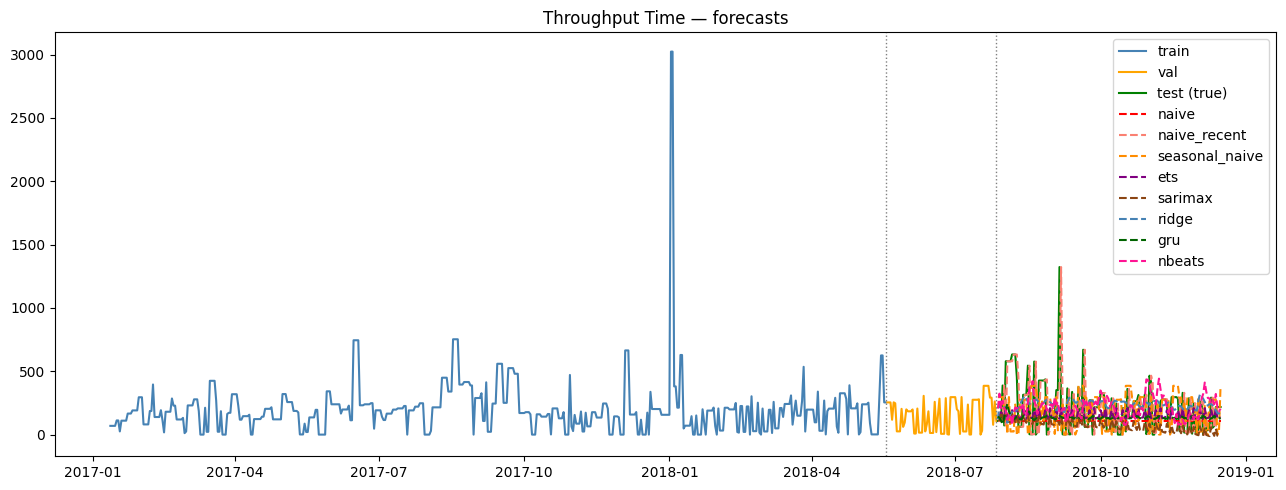

In [34]:
preds_tt = run_pipeline(train_tt, val_tt, test_tt, label="ThroughputTime")
plot_forecasts(train_tt, val_tt, test_tt, preds_tt, "Throughput Time — forecasts")

## Batch evaluation — all datasets

In [ ]:
import traceback
from pathlib import Path

import pandas as pd
import pm4py
from sklearn.metrics import mean_absolute_error, mean_squared_error

from time_series_creation import (
    create_concurrent_cases_timeseries,
    create_avg_throughtput_time_timeseries,
)
from time_series_preprocessing import apply_trim, split_timeseries
from time_series_prediction import run_pipeline


def evaluate_all_datasets(
    data_dir: str | Path,
    results_dir: str | Path,
    trim_method: str = "pct",
    trim_pct: float = 0.15,
    trim_k: float = 1.5,
    trim_frac: float = 0.60,
    trim_window: int = 7,
    train_frac: float = 0.7,
    val_frac: float = 0.1,
    test_frac: float = 0.2,
    models: list[str] | None = None,
    tuning: str = "small",
    include_naive_recent: bool = False,
    save_plots: bool = True,
) -> pd.DataFrame:
    """Run the full forecasting pipeline on every .xes file in data_dir.

    For each dataset, both concurrent_cases and throughput_time are evaluated.
    Per-model MSE and MAE on the test set are saved as CSVs under results_dir,
    and optionally a forecast plot PNG is saved alongside.

    Parameters
    ----------
    data_dir             : directory containing .xes event log files
    results_dir          : root directory where outputs are written
    trim_method          : tail-trimming method ("pct", "magnitude", "peak", None)
    trim_pct             : fraction to drop when trim_method="pct"
    trim_k               : std multiplier when trim_method="magnitude"
    trim_frac            : peak fraction when trim_method="peak"
    trim_window          : rolling window size for magnitude/peak methods
    train_frac           : fraction of trimmed series for training
    val_frac             : fraction for validation / HPO
    test_frac            : fraction for final evaluation
    models               : model subset; None runs all defaults (excludes naive_recent)
    tuning               : "small" or "large" grid search
    include_naive_recent : if True, also run the oracle naive_recent baseline
    save_plots           : if True, save a forecast PNG per series to results_dir

    Returns
    -------
    pd.DataFrame with columns: dataset, series, model, mse, mae
    """
    data_dir    = Path(data_dir)
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    cfg     = Split3WayConfig(train_frac=train_frac, val_frac=val_frac, test_frac=test_frac)
    trim_kw = dict(pct=trim_pct, k=trim_k, frac=trim_frac, window=trim_window)

    # build the effective models list
    if include_naive_recent:
        models_to_run = (models or [
            "naive", "seasonal_naive", "ets", "sarimax", "ridge", "gru", "nbeats",
        ]) + ["naive_recent"]
    else:
        models_to_run = models   # None → run_pipeline uses its own default (no naive_recent)

    all_rows: list[dict] = []

    xes_files = sorted(data_dir.glob("*.xes"))
    print(f"Found {len(xes_files)} dataset(s): {[f.stem for f in xes_files]}\n")

    series_map = {
        "concurrent_cases": create_concurrent_cases_timeseries,
        "throughput_time":  create_avg_throughtput_time_timeseries,
    }

    for xes_path in xes_files:
        dataset_name = xes_path.stem
        print(f"{'='*60}\nDataset: {dataset_name}\n{'='*60}")

        try:
            log = pm4py.read_xes(str(xes_path))
        except Exception:
            print(f"  [SKIP] failed to load:\n{traceback.format_exc()}")
            continue

        out_dir = results_dir / dataset_name
        out_dir.mkdir(parents=True, exist_ok=True)
        dataset_rows: list[dict] = []

        for series_name, series_fn in series_map.items():
            print(f"\n  -- {series_name} --")
            try:
                raw     = series_fn(log)
                trimmed = apply_trim(raw, trim_method, **trim_kw)
                print(f"  Trimmed: {len(raw)} → {len(trimmed)} observations")

                train, val, test = split_timeseries(trimmed, cfg)
                print(f"  Split: train={len(train)}, val={len(val)}, test={len(test)}")

                preds = run_pipeline(
                    train, val, test,
                    label=f"{dataset_name}/{series_name}",
                    models=models_to_run,
                    tuning=tuning,
                )

                if save_plots:
                    plot_forecasts(
                        train, val, test, preds,
                        title=f"{dataset_name} — {series_name}",
                        save_path=out_dir / f"{series_name}.png",
                    )

                y_test = test.to_numpy()
                for model_name, yhat in preds.items():
                    row = dict(
                        dataset=dataset_name,
                        series=series_name,
                        model=model_name,
                        mse=mean_squared_error(y_test, yhat),
                        mae=mean_absolute_error(y_test, yhat),
                    )
                    dataset_rows.append(row)
                    all_rows.append(row)

            except Exception:
                print(f"  [SKIP] {series_name} failed:\n{traceback.format_exc()}")
                continue

        if dataset_rows:
            pd.DataFrame(dataset_rows).to_csv(out_dir / "metrics.csv", index=False)
            print(f"\n  Saved → {out_dir}/metrics.csv" +
                  (f" + {series_name}.png" if save_plots else ""))

    results_df = pd.DataFrame(all_rows)
    if not results_df.empty:
        results_df.to_csv(results_dir / "metrics_all.csv", index=False)
        print(f"\nSaved combined → {results_dir}/metrics_all.csv")

    return results_df

Found 6 dataset(s): ['DomesticDeclarations', 'InternationalDeclarations', 'PermitLog', 'PrepaidTravelCost', 'RequestForPayment', 'bpic_12_A']

Dataset: DomesticDeclarations


parsing log, completed traces :: 100%|██████████| 10500/10500 [00:02<00:00, 4597.56it/s]



  -- concurrent_cases --


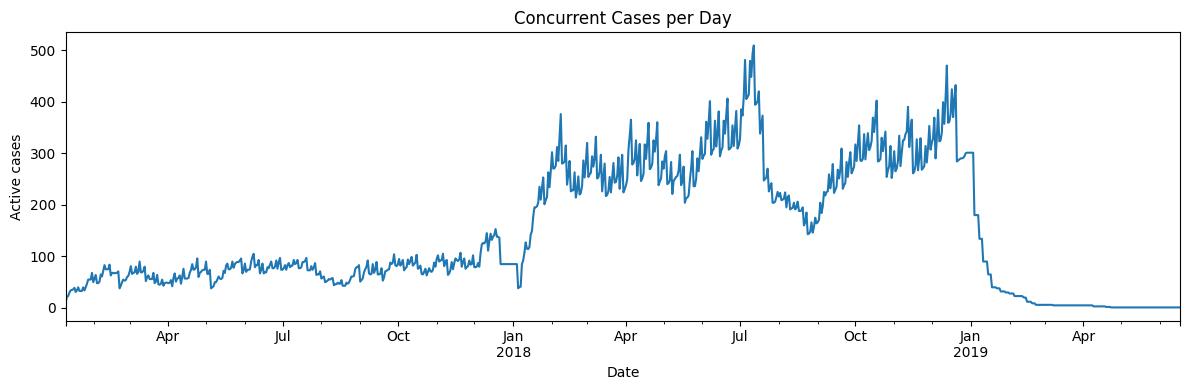

  Trimmed: 890 → 756 observations
  Split: train=529, val=75, test=152
[DomesticDeclarations/concurrent_cases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=12956.2400
[DomesticDeclarations/concurrent_cases] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': None, 'damped_trend': False, 'seasonal': 'mul', 'seasonal_periods': 7}  val_MSE=16875.9281
[DomesticDeclarations/concurrent_cases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 0, 0), 'seasonal_order': (1, 0, 0, 7)}  val_MSE=4085.5277
[DomesticDeclarations/concurrent_cases] Tuning ridge (12 candidates) …
  best: {'lags': 28, 'alpha': 10.0, 'add_time_features': True}  val_MSE=19340.2503
[DomesticDeclarations/concurrent_cases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.908290
  [GRU] epoch 2/50  loss=0.731272
  [GRU] epoch 3/50  loss=0.458303
  [GRU] epoch 4/50  loss=0.150907
  [GRU] epoch 5/50  loss=0.093943
  [GRU] epoch 6/50  loss=0.085425
  [GRU] epoch 7/50  loss=0.083363


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 46.2 K | train | 0    
---------------------------------------------------------------------
43.8 K    Trainable params
2.3 K     Non-trainable params
46.2 K    Total params
0.185     Total estim

Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 48.71it/s, train_loss=0.00863]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 48.44it/s, train_loss=0.00863]


...

Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 47.49it/s, train_loss=0.0107] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 47.30it/s, train_loss=0.0107]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 36.03it/s]

Model                      MSE         MAE
--------------------------------------------
naive               16498.0592    118.4671
naive_recent         1414.1579     25.3816
seasonal_naive      16832.5329    119.7171
ets                 14861.1930    112.7612
sarimax             19955.6258    127.6685
ridge               19826.6995    129.9643
gru                 31951.8256    157.9067
nbeats              12925.9476     86.0298

  -- throughput_time --


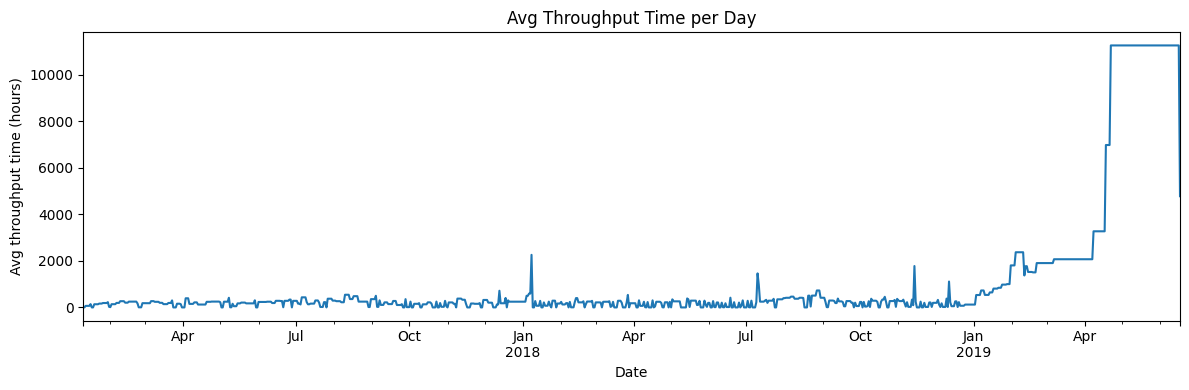

  Trimmed: 889 → 755 observations
  Split: train=528, val=75, test=152
[DomesticDeclarations/throughput_time] Tuning seasonal_naive (3 candidates) …
  best: {'season': 14}  val_MSE=118647.8850
[DomesticDeclarations/throughput_time] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'add', 'damped_trend': False, 'seasonal': None, 'seasonal_periods': 7}  val_MSE=100107.4416
[DomesticDeclarations/throughput_time] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 0), 'seasonal_order': (1, 0, 0, 7)}  val_MSE=74808.8455
[DomesticDeclarations/throughput_time] Tuning ridge (12 candidates) …
  best: {'lags': 14, 'alpha': 1.0, 'add_time_features': True}  val_MSE=70130.4652
[DomesticDeclarations/throughput_time] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=1.015724
  [GRU] epoch 2/50  loss=1.000026
  [GRU] epoch 3/50  loss=0.990014
  [GRU] epoch 4/50  loss=0.981029
  [GRU] epoch 5/50  loss=0.971790
  [GRU] epoch 6/50  loss=0.962832
  [GRU] epoch 7/50  loss=0.954494
  [

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 46.2 K | train | 0    
---------------------------------------------------------------------
43.8 K    Trainable params
2.3 K     Non-trainable params
46.2 K    Total params
0.185     Total estim

Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 48.71it/s, train_loss=0.00656]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 48.45it/s, train_loss=0.00656]


...

Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 47.80it/s, train_loss=0.00511]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 146.65it/s]

Model                      MSE         MAE
--------------------------------------------
naive              249215.7099    323.0311
naive_recent        70081.8567    122.0230
seasonal_naive     216276.1440    358.3794
ets                142389.1002    289.2900
sarimax            307462.7610    401.2421
ridge              172360.4337    246.6602
gru                176420.0365    263.1992
nbeats             173871.0933    251.7605

  Saved → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/DomesticDeclarations/metrics.csv
Dataset: InternationalDeclarations


parsing log, completed traces :: 100%|██████████| 6449/6449 [00:01<00:00, 3345.24it/s]



  -- concurrent_cases --


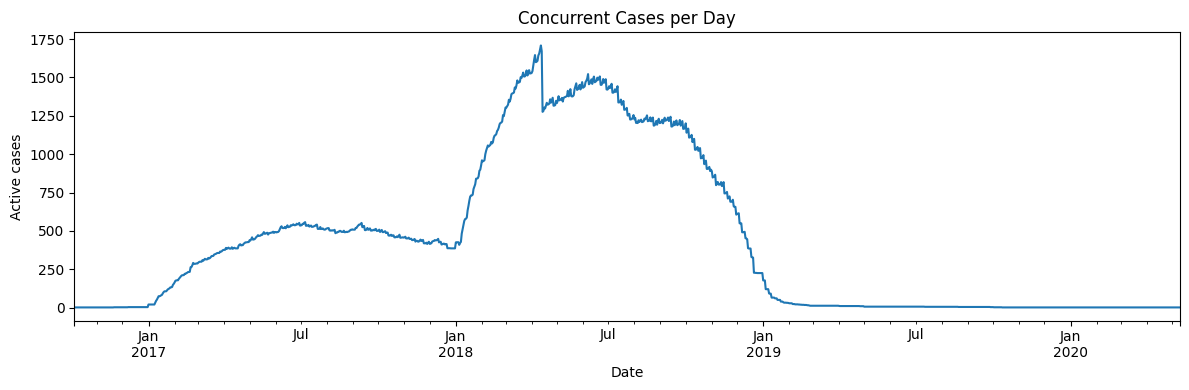

  Trimmed: 1314 → 1116 observations
  Split: train=781, val=111, test=224
[InternationalDeclarations/concurrent_cases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 7}  val_MSE=345516.7477
[InternationalDeclarations/concurrent_cases] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'add', 'damped_trend': False, 'seasonal': None, 'seasonal_periods': 7}  val_MSE=23476.4684
[InternationalDeclarations/concurrent_cases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 7)}  val_MSE=28785.2299
[InternationalDeclarations/concurrent_cases] Tuning ridge (12 candidates) …
  best: {'lags': 28, 'alpha': 1.0, 'add_time_features': True}  val_MSE=410501.7563
[InternationalDeclarations/concurrent_cases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.870851
  [GRU] epoch 2/50  loss=0.501232
  [GRU] epoch 3/50  loss=0.093904
  [GRU] epoch 4/50  loss=0.042529
  [GRU] epoch 5/50  loss=0.028658
  [GRU] epoch 6/50  loss=0.022610
  [GR

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 50.9 K | train | 0    
---------------------------------------------------------------------
48.6 K    Trainable params
2.3 K     Non-trainable params
50.9 K    Total params
0.204     Total estim

[InternationalDeclarations/concurrent_cases] Tuning nbeats (6 candidates) …


/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 49: 100%|██████████| 21/21 [00:00<00:00, 49.23it/s, train_loss=0.00542]

...

Epoch 49: 100%|██████████| 21/21 [00:00<00:00, 45.05it/s, train_loss=0.0085] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 21/21 [00:00<00:00, 44.92it/s, train_loss=0.0085]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 45.92it/s]

Model                      MSE         MAE
--------------------------------------------
naive                  45.2857      6.1161
naive_recent            0.0759      0.0491
seasonal_naive         45.2857      6.1161
ets                    38.7023      5.6704
sarimax             32715.6965    151.0583
ridge              185026.4589    395.8378
gru                166615.5792    339.6899
nbeats             135757.3999    304.8914

  -- throughput_time --


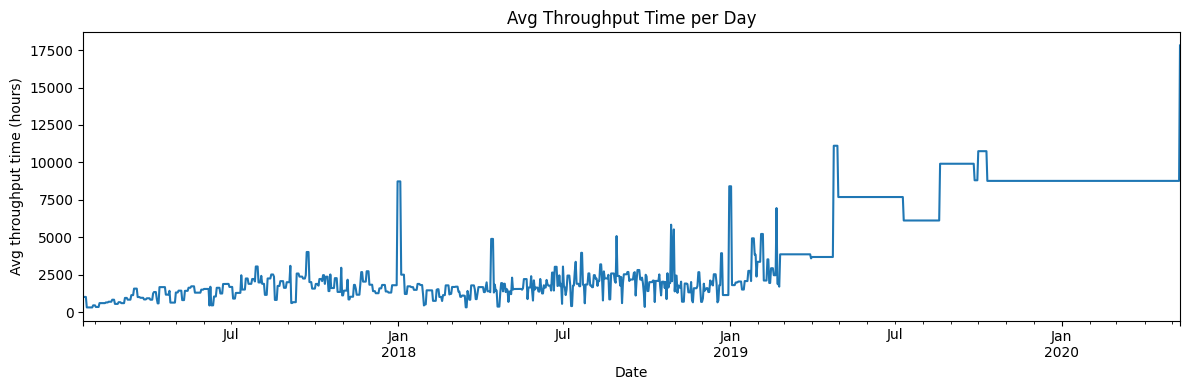

  Trimmed: 1208 → 1026 observations
  Split: train=718, val=102, test=206
[InternationalDeclarations/throughput_time] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=5739260.3673
[InternationalDeclarations/throughput_time] Tuning ets (30 candidates) …
  best: {'error': 'mul', 'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=776998.3428
[InternationalDeclarations/throughput_time] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 0)}  val_MSE=1874484.3391
[InternationalDeclarations/throughput_time] Tuning ridge (12 candidates) …
  best: {'lags': 28, 'alpha': 10.0, 'add_time_features': True}  val_MSE=4481719.7901
[InternationalDeclarations/throughput_time] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.957940
  [GRU] epoch 2/50  loss=0.925572
  [GRU] epoch 3/50  loss=0.897564
  [GRU] epoch 4/50  loss=0.869891
  [GRU] epoch 5/50  loss=0.851715
  [GRU] epoch 6/50  loss=0.843212
  

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 49.7 K | train | 0    
---------------------------------------------------------------------
47.4 K    Trainable params
2.3 K     Non-trainable params
49.7 K    Total params
0.199     Total estim

[InternationalDeclarations/throughput_time] Tuning nbeats (6 candidates) …


/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 49: 100%|██████████| 20/20 [00:00<00:00, 49.09it/s, train_loss=0.0206] 

...

Epoch 49: 100%|██████████| 19/19 [00:00<00:00, 47.71it/s, train_loss=0.0123]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 37.70it/s]

Model                      MSE         MAE
--------------------------------------------
naive             22035425.4496   4405.5693
naive_recent       449150.8281    103.0358
seasonal_naive    21496552.4817   4352.2684
ets               15932687.5377   3710.1050
sarimax           18675132.1935   4041.7365
ridge             34382653.2491   5565.8069
gru               22854969.2258   4497.0643
nbeats            56461271.6614   7155.7689

  Saved → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/InternationalDeclarations/metrics.csv
Dataset: PermitLog


parsing log, completed traces :: 100%|██████████| 7065/7065 [00:01<00:00, 3641.94it/s]



  -- concurrent_cases --


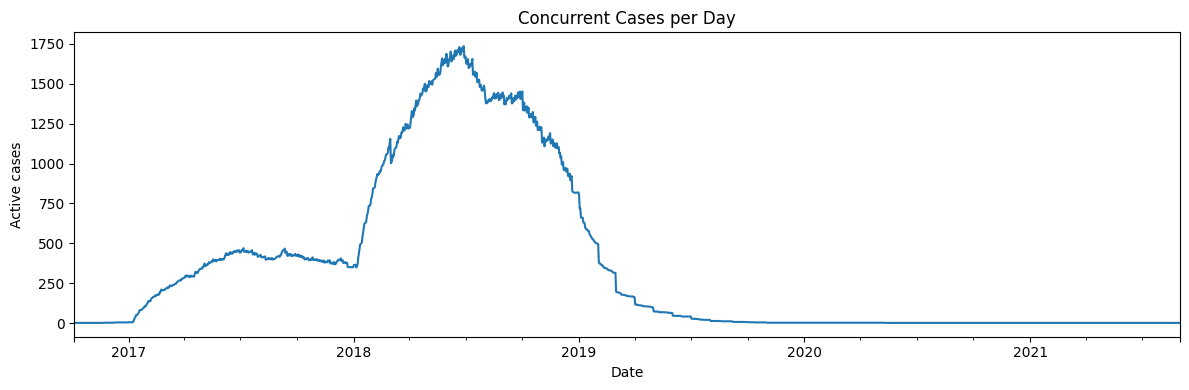

  Trimmed: 1793 → 1524 observations
  Split: train=1066, val=152, test=306
[PermitLog/concurrent_cases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 7}  val_MSE=62.6447
[PermitLog/concurrent_cases] Tuning ets (30 candidates) …
  best: {'error': 'mul', 'trend': 'mul', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=2.9787
[PermitLog/concurrent_cases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 0, 0), 'seasonal_order': (1, 1, 1, 7)}  val_MSE=41.8631
[PermitLog/concurrent_cases] Tuning ridge (12 candidates) …
  best: {'lags': 28, 'alpha': 10.0, 'add_time_features': True}  val_MSE=910.4319
[PermitLog/concurrent_cases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.827963
  [GRU] epoch 2/50  loss=0.260951
  [GRU] epoch 3/50  loss=0.041331
  [GRU] epoch 4/50  loss=0.024428
  [GRU] epoch 5/50  loss=0.018496
  [GRU] epoch 6/50  loss=0.014813
  [GRU] epoch 7/50  loss=0.012359
  [GRU] epoch 8/50  loss=0.010270
  [GRU] epoch 9/50  loss=0.0

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 56.3 K | train | 0    
---------------------------------------------------------------------
54.0 K    Trainable params
2.3 K     Non-trainable params
56.3 K    Total params
0.225     Total estim

Epoch 49: 100%|██████████| 29/29 [00:00<00:00, 45.91it/s, train_loss=0.0208] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 29/29 [00:00<00:00, 45.72it/s, train_loss=0.0208]


...

Epoch 49: 100%|██████████| 29/29 [00:00<00:00, 43.95it/s, train_loss=0.00805] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 29/29 [00:00<00:00, 43.87it/s, train_loss=0.00805]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 34.99it/s]

Model                      MSE         MAE
--------------------------------------------
naive                   0.6863      0.6863
naive_recent            0.0033      0.0033
seasonal_naive          0.6863      0.6863
ets                     0.5347      0.6146
sarimax                 1.6545      1.0517
ridge               77034.7095    254.9939
gru                 29668.1489    147.2103
nbeats             112886.0834    304.0485

  -- throughput_time --


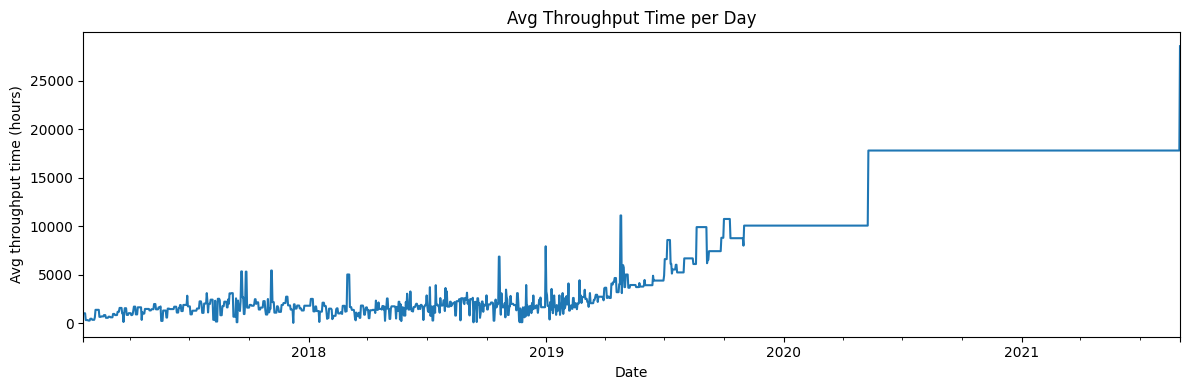

  Trimmed: 1687 → 1433 observations
  Split: train=1003, val=143, test=287
[PermitLog/throughput_time] Tuning seasonal_naive (3 candidates) …
  best: {'season': 14}  val_MSE=1216393.9526
[PermitLog/throughput_time] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=463356.5883
[PermitLog/throughput_time] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 0)}  val_MSE=159763.7809
[PermitLog/throughput_time] Tuning ridge (12 candidates) …
  best: {'lags': 28, 'alpha': 10.0, 'add_time_features': True}  val_MSE=5012187.1766
[PermitLog/throughput_time] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.864362
  [GRU] epoch 2/50  loss=0.513884
  [GRU] epoch 3/50  loss=0.265697
  [GRU] epoch 4/50  loss=0.230613
  [GRU] epoch 5/50  loss=0.220554
  [GRU] epoch 6/50  loss=0.214455
  [GRU] epoch 7/50  loss=0.208381
  [GRU] epoch 8/50  loss=0.205371
  [GRU] epoch 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[PermitLog/throughput_time] Tuning nbeats (6 candidates) …



  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 55.1 K | train | 0    
---------------------------------------------------------------------
52.8 K    Trainable params
2.3 K     Non-trainable params
55.1 K    Total params
0.221     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode
0         Total Flops
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated,

Epoch 49: 100%|██████████| 27/27 [00:00<00:00, 35.42it/s, train_loss=0.0121] 

...

Epoch 49: 100%|██████████| 27/27 [00:00<00:00, 49.07it/s, train_loss=0.0213]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 29.01it/s]

Model                      MSE         MAE
--------------------------------------------
naive             47184486.5138   6095.5499
naive_recent       208780.9138     26.9715
seasonal_naive    47184486.5138   6095.5499
ets               31083256.9959   4981.5591
sarimax           30318503.9114   4940.9084
ridge             11932680.8405   2948.6192
gru               43480269.3304   5913.3524
nbeats            29756359.9843   5132.1695

  Saved → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/PermitLog/metrics.csv
Dataset: PrepaidTravelCost


parsing log, completed traces :: 100%|██████████| 2099/2099 [00:00<00:00, 5558.27it/s]



  -- concurrent_cases --


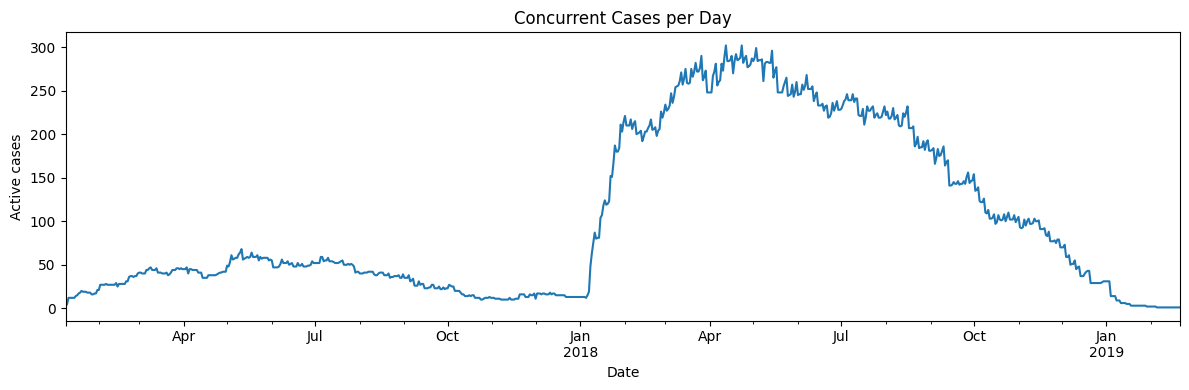

  Trimmed: 774 → 657 observations
  Split: train=459, val=65, test=133
[PrepaidTravelCost/concurrent_cases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=487.2615
[PrepaidTravelCost/concurrent_cases] Tuning ets (30 candidates) …
  best: {'error': 'mul', 'trend': None, 'damped_trend': False, 'seasonal': 'mul', 'seasonal_periods': 7}  val_MSE=793.3486
[PrepaidTravelCost/concurrent_cases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 0, 0), 'seasonal_order': (0, 0, 0, 0)}  val_MSE=1182.6061
[PrepaidTravelCost/concurrent_cases] Tuning ridge (12 candidates) …
  best: {'lags': 14, 'alpha': 10.0, 'add_time_features': True}  val_MSE=2315.5893
[PrepaidTravelCost/concurrent_cases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.933972
  [GRU] epoch 2/50  loss=0.804471
  [GRU] epoch 3/50  loss=0.618068
  [GRU] epoch 4/50  loss=0.324425
  [GRU] epoch 5/50  loss=0.102794
  [GRU] epoch 6/50  loss=0.055229
  [GRU] epoch 7/50  loss=0.041358
  [GRU] epoch 8/50  

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 44.8 K | train | 0    
---------------------------------------------------------------------
42.5 K    Trainable params
2.3 K     Non-trainable params
44.8 K    Total params
0.179     Total estim

Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 48.30it/s, train_loss=0.0159]  

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 13/13 [00:00<00:00, 48.15it/s, train_loss=0.0159]


...

Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 50.14it/s, train_loss=0.0184] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 49.83it/s, train_loss=0.0184]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 23.88it/s]

Model                      MSE         MAE
--------------------------------------------
naive                4540.8346     49.7669
naive_recent           65.1805      5.6767
seasonal_naive       6489.5188     65.3233
ets                  5316.2270     56.0894
sarimax              2829.0841     38.1634
ridge                 732.1407     23.2418
gru                  9236.9854     80.6181
nbeats               1212.7154     26.3828

  -- throughput_time --


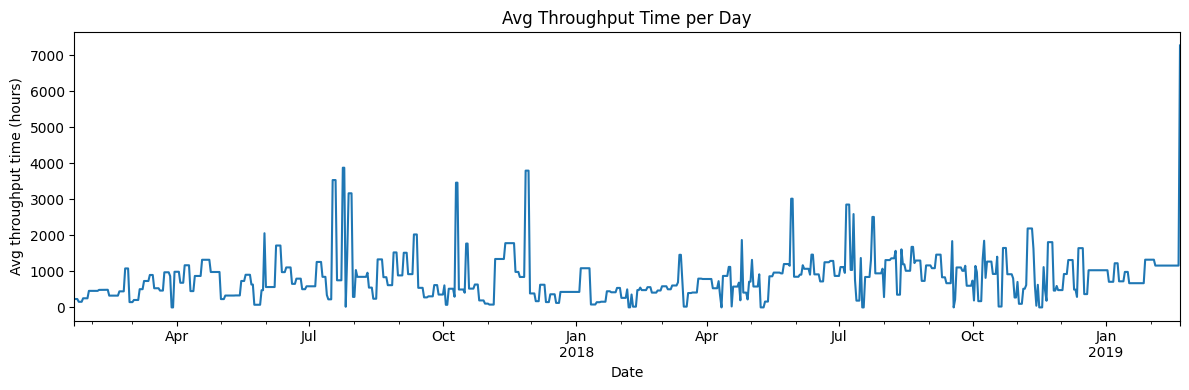

  Trimmed: 763 → 648 observations
  Split: train=453, val=64, test=131
[PrepaidTravelCost/throughput_time] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=344656.9514
[PrepaidTravelCost/throughput_time] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'add', 'damped_trend': True, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=316838.3617
[PrepaidTravelCost/throughput_time] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 0), 'seasonal_order': (1, 1, 1, 7)}  val_MSE=301374.4193
[PrepaidTravelCost/throughput_time] Tuning ridge (12 candidates) …
  best: {'lags': 14, 'alpha': 10.0, 'add_time_features': True}  val_MSE=245040.3604
[PrepaidTravelCost/throughput_time] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=1.026664
  [GRU] epoch 2/50  loss=0.999543
  [GRU] epoch 3/50  loss=0.977772
  [GRU] epoch 4/50  loss=0.957961
  [GRU] epoch 5/50  loss=0.936573
  [GRU] epoch 6/50  loss=0.922646
  [GRU] epoch 7/50  loss=0.915879
  [GRU] epoch 8

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 44.7 K | train | 0    
---------------------------------------------------------------------
42.4 K    Trainable params
2.3 K     Non-trainable params
44.7 K    Total params
0.179     Total estim

Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 45.12it/s, train_loss=0.0288]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 44.83it/s, train_loss=0.0288]


...

Epoch 49: 100%|██████████| 12/12 [00:00<00:00, 45.25it/s, train_loss=0.0314]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 26.95it/s]

Model                      MSE         MAE
--------------------------------------------
naive              413407.4676    495.5409
naive_recent       339490.6902    303.3309
seasonal_naive     665110.4108    553.5306
ets                457705.4967    534.3590
sarimax            705287.4312    705.2488
ridge              302898.7315    391.4795
gru                538502.9736    593.5866
nbeats             326274.1923    415.7687

  Saved → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/PrepaidTravelCost/metrics.csv
Dataset: RequestForPayment


parsing log, completed traces :: 100%|██████████| 6886/6886 [00:00<00:00, 9510.28it/s] 



  -- concurrent_cases --


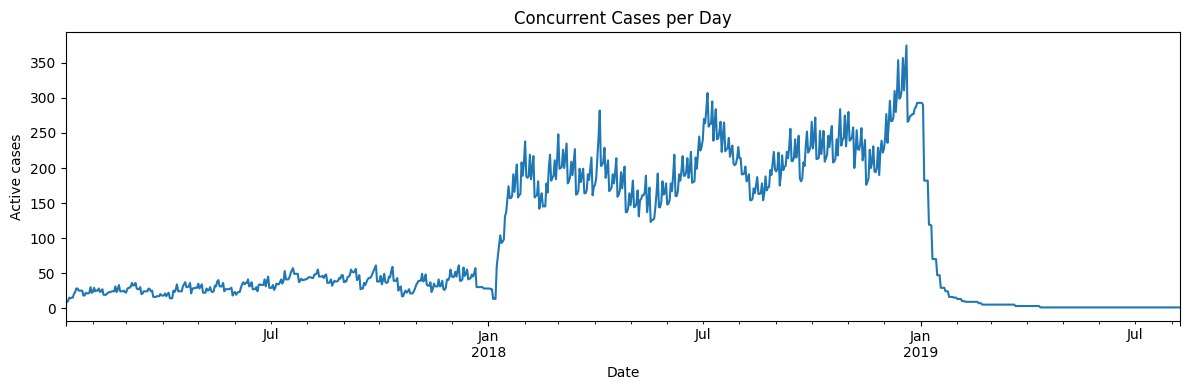

  Trimmed: 942 → 800 observations
  Split: train=560, val=80, test=160
[RequestForPayment/concurrent_cases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 7}  val_MSE=1920.2375
[RequestForPayment/concurrent_cases] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'mul', 'damped_trend': True, 'seasonal': None, 'seasonal_periods': 7}  val_MSE=1218.9288
[RequestForPayment/concurrent_cases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 1), 'seasonal_order': (1, 0, 0, 7)}  val_MSE=1266.3163
[RequestForPayment/concurrent_cases] Tuning ridge (12 candidates) …
  best: {'lags': 7, 'alpha': 10.0, 'add_time_features': True}  val_MSE=2164.9272
[RequestForPayment/concurrent_cases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.927987
  [GRU] epoch 2/50  loss=0.735109
  [GRU] epoch 3/50  loss=0.411415
  [GRU] epoch 4/50  loss=0.134570
  [GRU] epoch 5/50  loss=0.093212
  [GRU] epoch 6/50  loss=0.087269
  [GRU] epoch 7/50  loss=0.081596
  [GRU] epoch 8/50  l

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 46.8 K | train | 0    
---------------------------------------------------------------------
44.5 K    Trainable params
2.3 K     Non-trainable params
46.8 K    Total params
0.187     Total estim

[RequestForPayment/concurrent_cases] Tuning nbeats (6 candidates) …


/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 49: 100%|██████████| 15/15 [00:00<00:00, 37.16it/s, train_loss=0.0172] 

...

Epoch 49: 100%|██████████| 15/15 [00:00<00:00, 26.49it/s, train_loss=0.0269] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 15/15 [00:00<00:00, 26.32it/s, train_loss=0.0269]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 39.68it/s]

Model                      MSE         MAE
--------------------------------------------
naive               21822.1875    114.8250
naive_recent          572.3188     13.3812
seasonal_naive      21380.3125    112.6750
ets                 21323.5663    113.8814
sarimax             29413.3415    128.3043
ridge               36909.6049    141.4896
gru                 18793.8751    109.9762
nbeats              20750.7573    117.3344

  -- throughput_time --


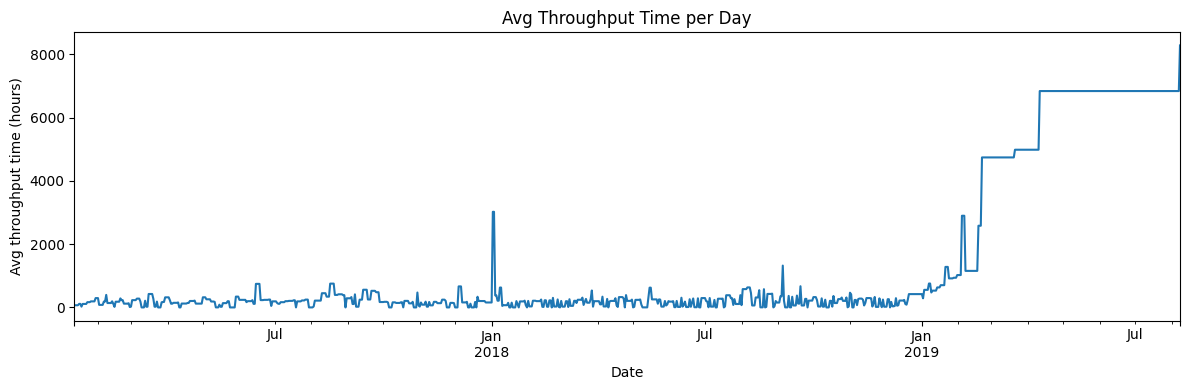

  Trimmed: 939 → 798 observations
  Split: train=558, val=79, test=161
[RequestForPayment/throughput_time] Tuning seasonal_naive (3 candidates) …
  best: {'season': 14}  val_MSE=75536.5444
[RequestForPayment/throughput_time] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': None, 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=52100.5369
[RequestForPayment/throughput_time] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 0), 'seasonal_order': (0, 1, 1, 7)}  val_MSE=49737.3580
[RequestForPayment/throughput_time] Tuning ridge (12 candidates) …
  best: {'lags': 7, 'alpha': 10.0, 'add_time_features': True}  val_MSE=58844.3818
[RequestForPayment/throughput_time] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=1.030890
  [GRU] epoch 2/50  loss=1.018028
  [GRU] epoch 3/50  loss=1.009891
  [GRU] epoch 4/50  loss=1.002186
  [GRU] epoch 5/50  loss=0.996250
  [GRU] epoch 6/50  loss=0.991959
  [GRU] epoch 7/50  loss=0.988301
  [GRU] epoch 8/50  

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 46.7 K | train | 0    
---------------------------------------------------------------------
44.4 K    Trainable params
2.3 K     Non-trainable params
46.7 K    Total params
0.187     Total estim

Epoch 49: 100%|██████████| 15/15 [00:00<00:00, 48.74it/s, train_loss=0.00374]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 15/15 [00:00<00:00, 48.58it/s, train_loss=0.00374]


...

Epoch 49: 100%|██████████| 15/15 [00:00<00:00, 39.40it/s, train_loss=0.0054]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 67.47it/s]

Model                      MSE         MAE
--------------------------------------------
naive             4389311.0110   1249.2838
naive_recent        98229.1396    107.6423
seasonal_naive    4017781.2238   1150.9880
ets               4305952.1224   1217.2514
sarimax           5006590.1322   1382.6234
ridge             4056423.3927   1147.4170
gru               4163591.4739   1170.5303
nbeats            3975420.0684   1135.2212

  Saved → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/RequestForPayment/metrics.csv
Dataset: bpic_12_A


parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 7602.28it/s]



  -- concurrent_cases --


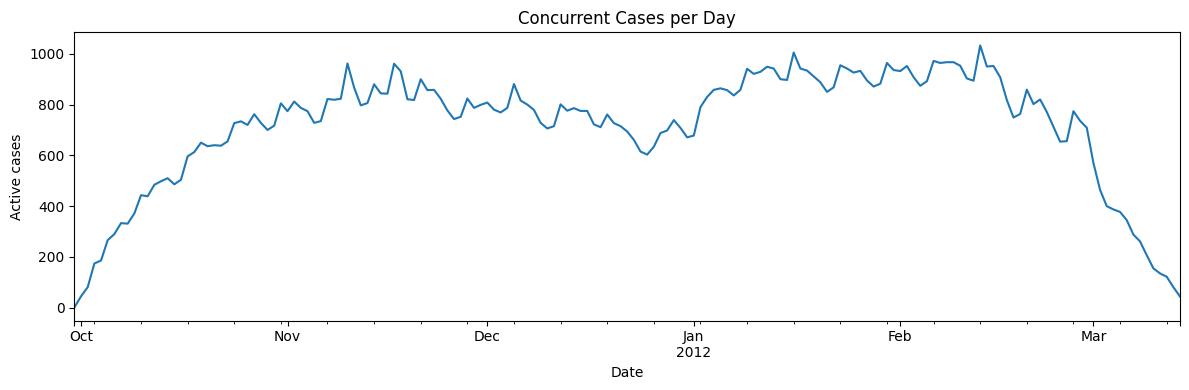

  Trimmed: 167 → 141 observations
  Split: train=98, val=14, test=29
[bpic_12_A/concurrent_cases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 7}  val_MSE=24791.8571
[bpic_12_A/concurrent_cases] Tuning ets (30 candidates) …
  best: {'error': 'mul', 'trend': 'add', 'damped_trend': True, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=1243.7396
[bpic_12_A/concurrent_cases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 0, 0), 'seasonal_order': (1, 0, 0, 7)}  val_MSE=1120.1279
[bpic_12_A/concurrent_cases] Tuning ridge (12 candidates) …
  best: None  val_MSE=inf
[bpic_12_A/concurrent_cases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.362241
  [GRU] epoch 2/50  loss=0.337806
  [GRU] epoch 3/50  loss=0.313270
  [GRU] epoch 4/50  loss=0.290938
  [GRU] epoch 5/50  loss=0.267217
  [GRU] epoch 6/50  loss=0.245580
  [GRU] epoch 7/50  loss=0.222808
  [GRU] epoch 8/50  loss=0.200604
  [GRU] epoch 9/50  loss=0.176914
  [GRU] epoch 10/50  loss=0.157929
  [GRU] epoch

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 38.1 K | train | 0    
---------------------------------------------------------------------
35.8 K    Trainable params
2.3 K     Non-trainable params
38.1 K    Total params
0.152     Total estim

Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 41.63it/s, train_loss=0.00504]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 40.86it/s, train_loss=0.00504]


...

Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 44.33it/s, train_loss=0.00779]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 43.73it/s, train_loss=0.00779]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 80.91it/s]

Model                      MSE         MAE
--------------------------------------------
naive                2115.8621     38.4138
naive_recent         2390.3793     35.4138
seasonal_naive       1390.7931     27.6207
ets                  1465.4069     31.3720
sarimax             13781.3242     98.7555
ridge               11806.1703     83.3257
gru                 13967.4224     93.9061
nbeats              15242.6228    110.7919

  -- throughput_time --


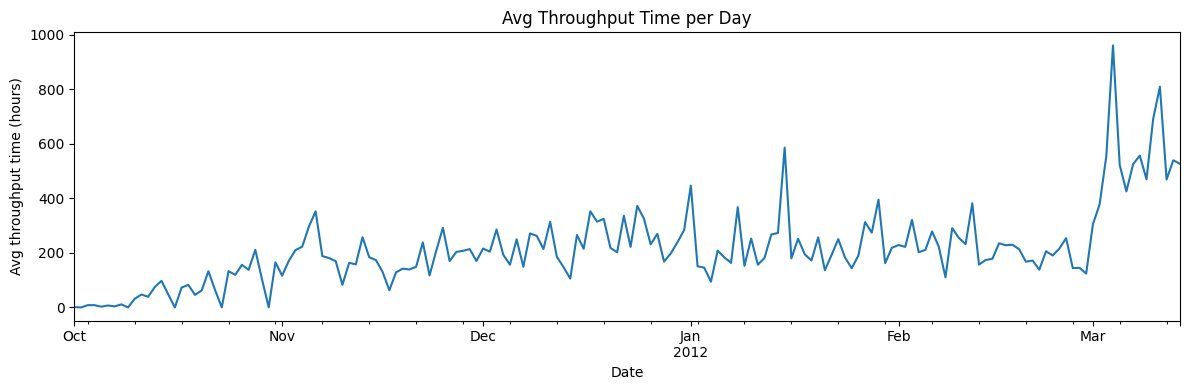

  Trimmed: 166 → 141 observations
  Split: train=98, val=14, test=29
[bpic_12_A/throughput_time] Tuning seasonal_naive (3 candidates) …
  best: {'season': 7}  val_MSE=6593.4623
[bpic_12_A/throughput_time] Tuning ets (30 candidates) …


/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:584: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


  best: {'error': 'add', 'trend': 'add', 'damped_trend': True, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=8029.0917
[bpic_12_A/throughput_time] Tuning sarimax (16 candidates) …
  best: {'order': (1, 0, 0), 'seasonal_order': (1, 1, 1, 7)}  val_MSE=7153.0035
[bpic_12_A/throughput_time] Tuning ridge (12 candidates) …
  best: None  val_MSE=inf
[bpic_12_A/throughput_time] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.838613
  [GRU] epoch 2/50  loss=0.816994
  [GRU] epoch 3/50  loss=0.796415
  [GRU] epoch 4/50  loss=0.774943
  [GRU] epoch 5/50  loss=0.754647
  [GRU] epoch 6/50  loss=0.734941
  [GRU] epoch 7/50  loss=0.713994
  [GRU] epoch 8/50  loss=0.692726
  [GRU] epoch 9/50  loss=0.673360
  [GRU] epoch 10/50  loss=0.649703
  [GRU] epoch 11/50  loss=0.630792
  [GRU] epoch 12/50  loss=0.608929
  [GRU] epoch 13/50  loss=0.593167
  [GRU] epoch 14/50  loss=0.579607
  [GRU] epoch 15/50  loss=0.568878
  [GRU] epoch 16/50  loss=0.565227
  [GRU] epoch 17/50  loss=0.557099
  [GRU] 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 38.1 K | train | 0    
---------------------------------------------------------------------
35.8 K    Trainable params
2.3 K     Non-trainable params
38.1 K    Total params
0.152     Total estim

Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 39.28it/s, train_loss=0.0216]

...

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 2/2 [00:00<00:00, 43.37it/s, train_loss=0.0131]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 151.72it/s]

Model                      MSE         MAE
--------------------------------------------
naive                5215.2514     60.1772
naive_recent         9418.8566     73.7323
seasonal_naive      16181.2071     84.8878
ets                  6508.4725     58.0491
sarimax             14801.2276     95.0406
ridge               13084.3988     87.8985
gru                  4635.2243     55.3572
nbeats               6518.0648     67.3760

  Saved → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/bpic_12_A/metrics.csv

Saved combined results → /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results/metrics_all.csv


,dataset,series,model,mse,mae
0,DomesticDeclarations,concurrent_cases,naive,16498.059211,118.467105
1,DomesticDeclarations,concurrent_cases,naive_recent,1414.157895,25.381579
2,DomesticDeclarations,concurrent_cases,seasonal_naive,16832.532895,119.717105
3,DomesticDeclarations,concurrent_cases,ets,14861.192970,112.761217
4,DomesticDeclarations,concurrent_cases,sarimax,19955.625819,127.668475
...,...,...,...,...,...
91,bpic_12_A,throughput_time,ets,6508.472538,58.049147
92,bpic_12_A,throughput_time,sarimax,14801.227586,95.040647
93,bpic_12_A,throughput_time,ridge,13084.398785,87.898520
94,bpic_12_A,throughput_time,gru,4635.224296,55.357212


In [36]:
results = evaluate_all_datasets(
    data_dir    = ROOT / "data",
    results_dir = ROOT / "results",
    trim_method = "pct",
    trim_pct    = 0.15,
    tuning      = "small",
    # models    = ["naive", "ets", "sarimax"],  # uncomment to run a subset
)
results